In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def getStructuringElement(shape: str, size: int):
    shape = shape.lower().strip()
    if shape == 'rect':
        return cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    elif shape == 'disk':
        return cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(size, size))
    elif shape == 'cross':
        return cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))
    elif shape == 'horizontal':
        kernel = np.zeros((1, size))
        kernel[0, :] = 1
        return kernel
    elif shape == 'vertical':
        kernel = np.zeros((size, 1))
        kernel[:, 0] = 1
        return kernel

def dilate(image: np.ndarray, shape: str, size: int):
    kernel = getStructuringElement(shape, size)
    return cv2.dilate(image, kernel)


def erode(image: np.ndarray, shape: str, size: int):
    kernel = getStructuringElement(shape, size)
    return cv2.erode(image, kernel)

In [ ]:
IMAGE_PATH = "original_image.png" 
KERNEL_SIZE = 15


original_image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
_, binary_image = cv2.threshold(original_image, 127, 255, cv2.THRESH_BINARY)

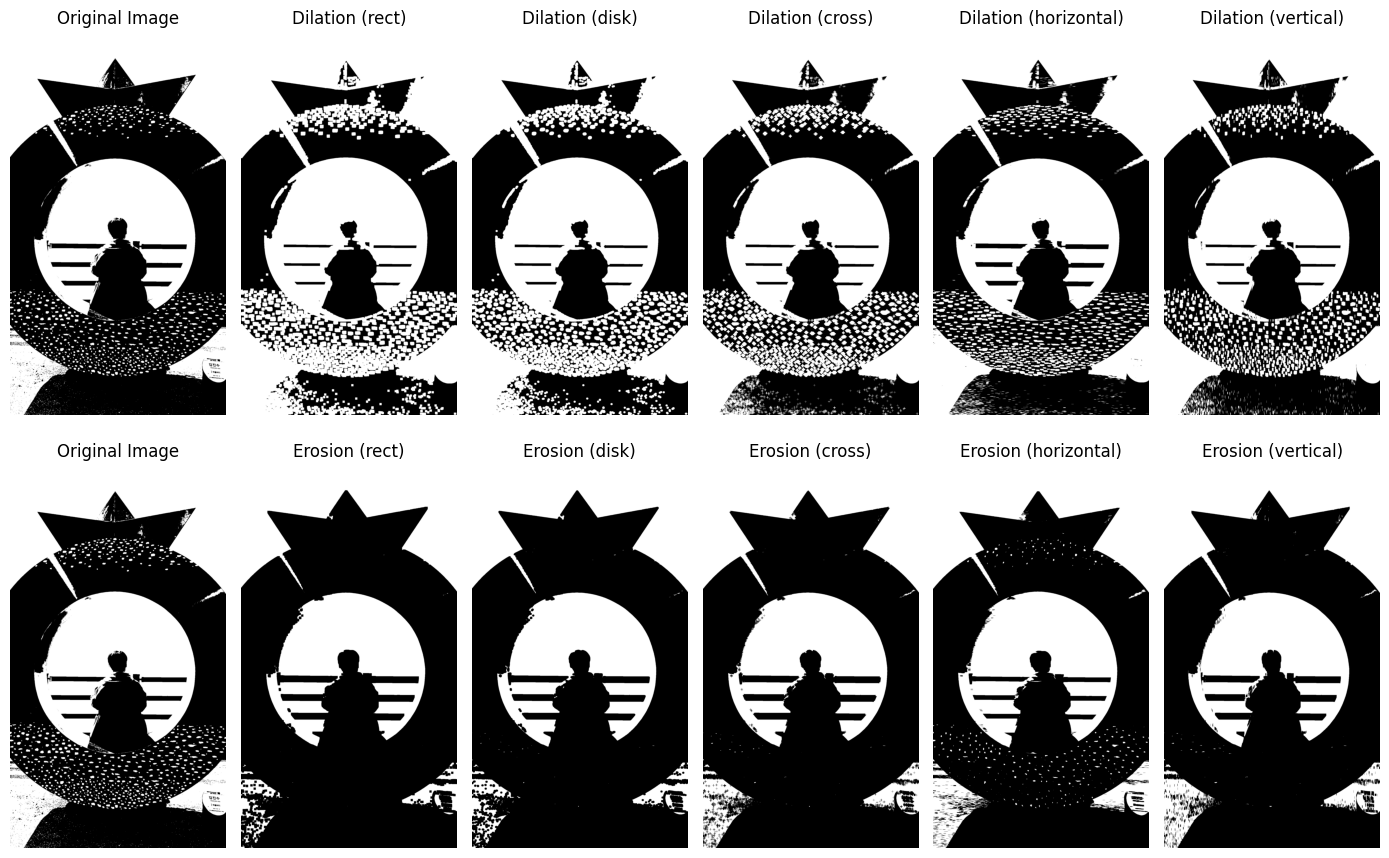

In [11]:
shapes = ['rect', 'disk', 'cross', 'horizontal', 'vertical']

fig, axes = plt.subplots(2, 6, figsize=(14, 9))

axes[0, 0].imshow(binary_image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image', fontsize=12)
axes[0, 0].axis('off')

axes[1, 0].imshow(binary_image, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Original Image', fontsize=12)
axes[1, 0].axis('off')

for col, shape in enumerate(shapes):
    d = dilate(binary_image, shape, KERNEL_SIZE)
    e = erode(binary_image, shape, KERNEL_SIZE)

    axes[0, col + 1].imshow(d, cmap='gray', vmin=0, vmax=255)
    axes[0, col + 1].set_title(f'Dilation ({shape})', fontsize=12)
    axes[0, col + 1].axis('off')

    axes[1, col + 1].imshow(e, cmap='gray', vmin=0, vmax=255)
    axes[1, col + 1].set_title(f'Erosion ({shape})', fontsize=12)
    axes[1, col + 1].axis('off')

plt.tight_layout()
plt.show()